In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
heart_df = pd.read_csv('data/heart-attack/heart.csv')

In [4]:
heart_df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [27]:
heart_df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [6]:
heart_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trtbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalachh,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exng,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [24]:
categorical_vars = ["sex","cp","fbs","restecg","exng","slp","caa","thall"]
numerical_vars = []
for col in heart_df.columns:
    if col in categorical_vars:
        pass
    else:
        numerical_vars.append(col)


In [25]:
numerical_vars

['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'output']

In [26]:
heart_df[numerical_vars].corr()["output"].apply(abs).sort_values(ascending=False)

output      1.000000
oldpeak     0.430696
thalachh    0.421741
age         0.225439
trtbps      0.144931
chol        0.085239
Name: output, dtype: float64

[]

<Figure size 1080x720 with 0 Axes>

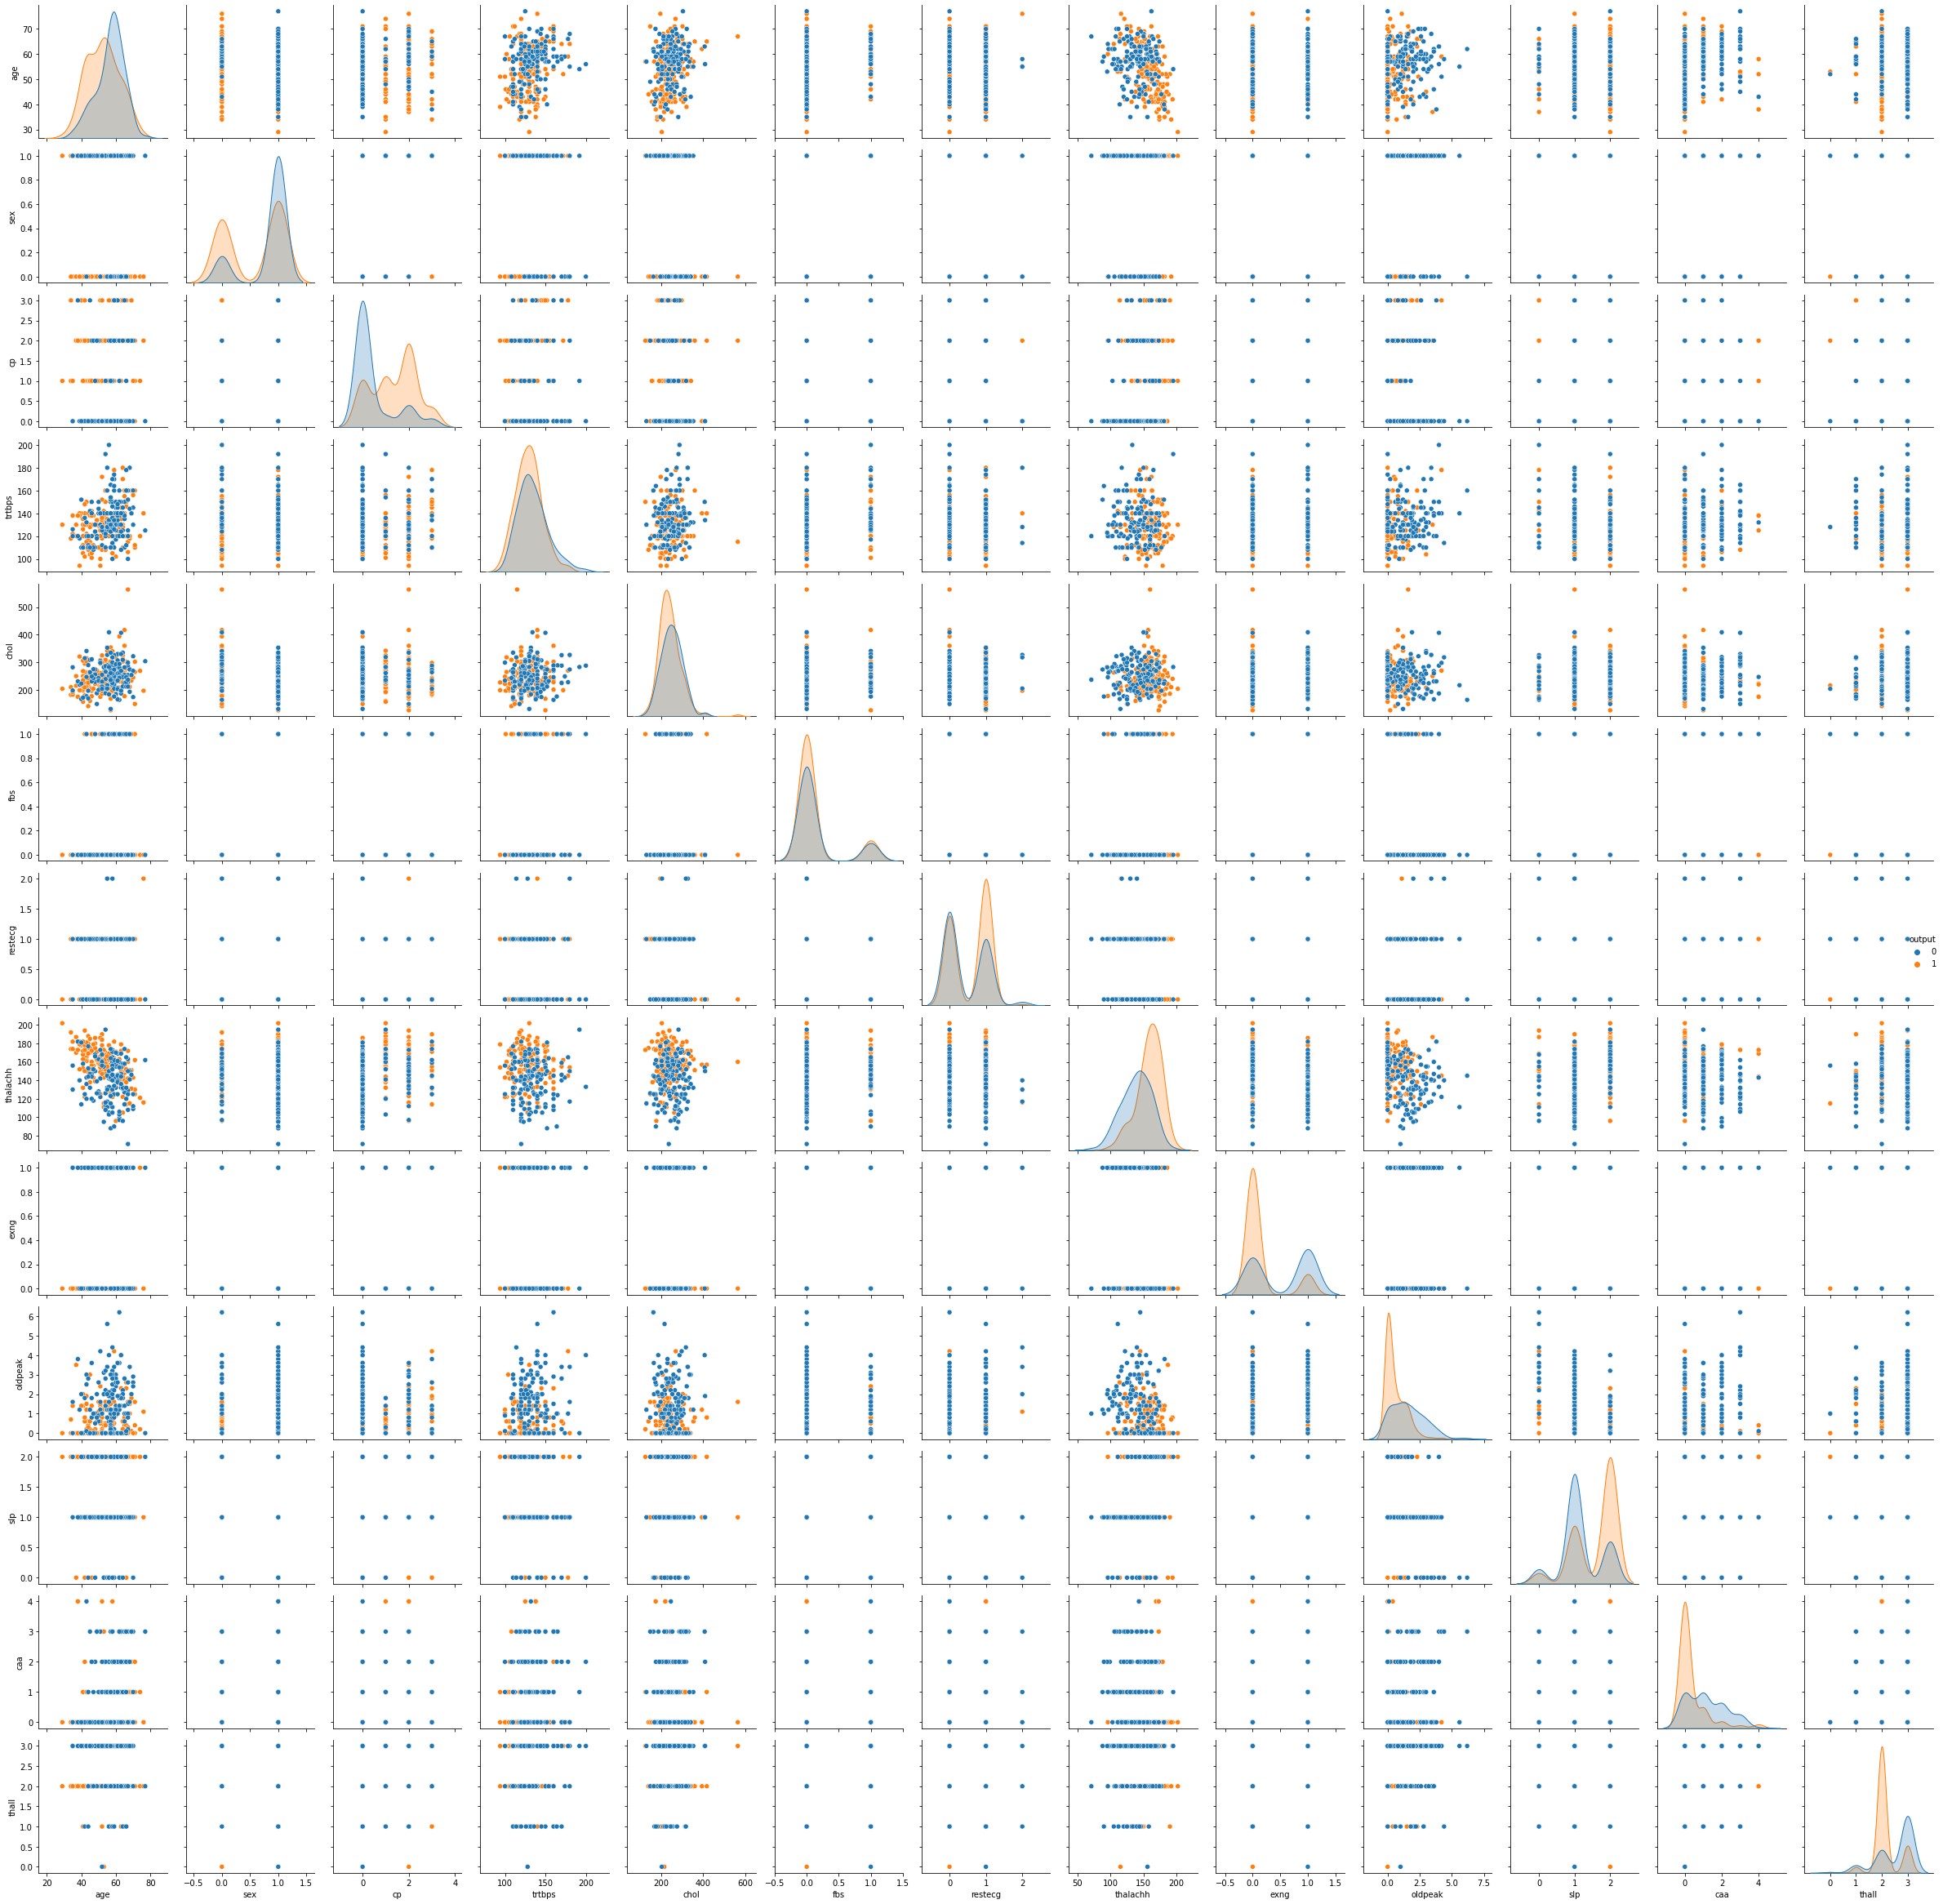

In [31]:
plt.figure(figsize=(15,10))
sns.pairplot(heart_df,hue="output",diag_kind='kde')
plt.tight_layout()
plt.plot()

In [32]:
df_cleaned = heart_df.copy()


# Loop through each numerical variable to remove outliers
for var in numerical_vars:
    # Calculate Q1 and Q3
    Q1 = df_cleaned[var].quantile(0.25)
    Q3 = df_cleaned[var].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define the outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out the outliers
    df_cleaned = df_cleaned[(df_cleaned[var] >= lower_bound) & (df_cleaned[var] <= upper_bound)]

In [33]:
df_cleaned.shape

(284, 14)

In [35]:
df_cleaned = pd.get_dummies(df_cleaned,columns=categorical_vars)

In [72]:
df_cleaned.columns[df_cleaned.isnull().any()]

Index([], dtype='object')

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = imputer.fit(df[['Weight']])
df['Weight'] = imputer.transform(df[['Weight']])

In [36]:
df_cleaned

,age,trtbps,chol,thalachh,oldpeak,output,sex_0,sex_1,cp_0,cp_1,...,slp_2,caa_0,caa_1,caa_2,caa_3,caa_4,thall_0,thall_1,thall_2,thall_3
0,63,145,233,150,2.3,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,37,130,250,187,3.5,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
2,41,130,204,172,1.4,1,1,0,0,1,...,1,1,0,0,0,0,0,0,1,0
3,56,120,236,178,0.8,1,0,1,0,1,...,1,1,0,0,0,0,0,0,1,0
4,57,120,354,163,0.6,1,1,0,1,0,...,1,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0.2,0,1,0,1,0,...,0,1,0,0,0,0,0,0,0,1
299,45,110,264,132,1.2,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
300,68,144,193,141,3.4,0,0,1,1,0,...,0,0,0,1,0,0,0,0,0,1
301,57,130,131,115,1.2,0,0,1,1,0,...,0,0,1,0,0,0,0,0,0,1


In [42]:
from sklearn.model_selection import train_test_split
X = df_cleaned.drop('output',axis=1)
y = df_cleaned['output']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression

logres = LogisticRegression()

logres.fit(X_train_scaled,y_train)


LogisticRegression()

In [55]:
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,f1_score

y_pred = logres.predict(X_test_scaled)
y_pred_probs = logres.predict_proba(X_test_scaled)
print('Accuracy Score : ',accuracy_score(y_test,y_pred))
print('roc_auc_score Score : ',roc_auc_score(y_test,y_pred_probs[:,1]))
print('f1 Score : ',f1_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy Score :  0.8947368421052632
roc_auc_score Score :  0.9516129032258065
f1 Score :  0.896551724137931
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        26
           1       0.96      0.84      0.90        31

    accuracy                           0.89        57
   macro avg       0.90      0.90      0.89        57
weighted avg       0.90      0.89      0.89        57



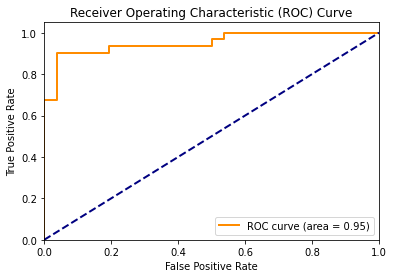

In [59]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [63]:
import optuna
from xgboost import XGBClassifier
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.01, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'alpha': trial.suggest_float('alpha', 0, 10),
        'lambda': trial.suggest_float('lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10)
    }
    
    model = XGBClassifier(**params, objective="binary:logistic",eval_metric="logloss")
    
    # Perform k-fold cross-validation
    #cv_scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
    # Train Test Split
    X_train2, X_test2, y_train2, y_test2 = train_test_split(X_train_scaled,y_train, test_size=0.2, random_state=42)
    model.fit(X_train2, y_train2)
    y_pred = model.predict(X_test2)
    # Calculate gini score
    accuracy = accuracy_score(y_test2, y_pred)
    
    # Return the mean cross-validation score
    return accuracy

# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Best parameters
best_params = study.best_params
print('Best parameters:', best_params)

# Best score
best_score = study.best_value
print('Best accuracy score:', best_score)

[I 2024-10-29 11:34:28,829] A new study created in memory with name: no-name-4844f97f-dbf8-4ed6-99fd-153adde9486a
c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
[I 2024-10-29 11:34:29,348] Trial 0 finished with value: 0.8260869565217391 and parameters: {'n_estimators': 759, 'max_depth': 17, 'learning_rate': 0.159947607830539, 'subsample': 0.9928028554497854, 'colsample_bytree': 0.7200660506459824, 'min_child_weight': 8, 'gamma': 0.8781699342975952, 'alpha': 1.7940273775527504, 'lambda': 4.086920402986999, 'scale_pos_weight': 4.563180903433276}. Best is trial 0 with value: 0.826086

Best parameters: {'n_estimators': 528, 'max_depth': 12, 'learning_rate': 0.1749797653740388, 'subsample': 0.4952413905134259, 'colsample_bytree': 0.5305170526081864, 'min_child_weight': 1, 'gamma': 0.09866928647866102, 'alpha': 4.619606563408518, 'lambda': 3.328259793167776, 'scale_pos_weight': 8.47354747535666}
Best accuracy score: 0.8695652173913043


In [64]:
best_model = XGBClassifier(**best_params,objective="binary:logistic",eval_metric="logloss")
best_model.fit(X_train_scaled,y_train)

y_pred = best_model.predict(X_test_scaled)
y_pred_probs = best_model.predict_proba(X_test_scaled)
print('Accuracy Score : ',accuracy_score(y_test,y_pred))
print('roc_auc_score Score : ',roc_auc_score(y_test,y_pred_probs[:,1]))
print('f1 Score : ',f1_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

c:\Users\yasin.secal\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


Accuracy Score :  0.7719298245614035
roc_auc_score Score :  0.9404466501240695
f1 Score :  0.8169014084507041
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        26
           1       0.72      0.94      0.82        31

    accuracy                           0.77        57
   macro avg       0.80      0.76      0.76        57
weighted avg       0.80      0.77      0.76        57



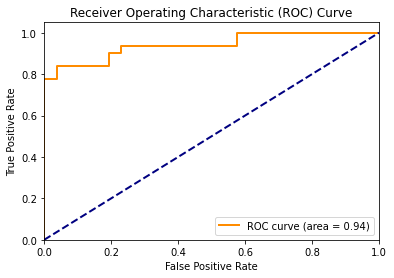

In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

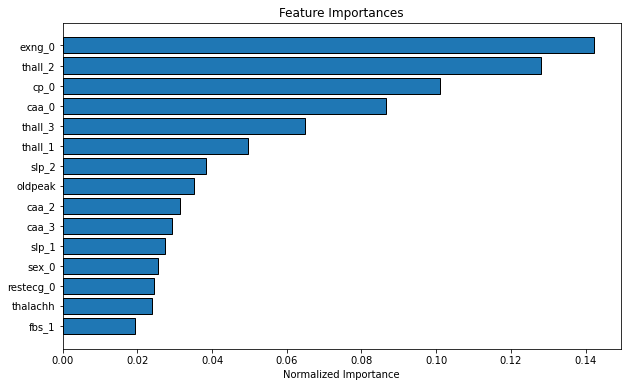

In [74]:
 # Feature Importance
# Get feature importances
feature_importance = best_model.feature_importances_
feature_names = X_train.columns

# Create a dataframe of feature importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
})

    # Sort features according to importance
df = feature_importance_df.sort_values('importance', ascending = False).reset_index()

# Normalize the feature importances to add up to one
df['importance_normalized'] = df['importance'] / df['importance'].sum()
# Make a horizontal bar chart of feature importances
plt.figure(figsize = (10, 6))
ax = plt.subplot()

# Need to reverse the index to plot most important on top
ax.barh(list(reversed(list(df.index[:15]))), 
        df['importance_normalized'].head(15), 
        align = 'center', edgecolor = 'k')

# Set the yticks and labels
ax.set_yticks(list(reversed(list(df.index[:15]))))
ax.set_yticklabels(df['feature'].head(15))

# Plot labeling
plt.xlabel('Normalized Importance'); plt.title('Feature Importances')
plt.show()